# Thesis 2024 - 2025
## UGBS
### Isil Oral

* Project on green gentrification in Vienna through social status index, green spaces, blue areas, and housing prices 

## Part 1 - Intro
uploading data files, processing, and creating necessary (geo)dataframes

In [1]:
pip install osmnx==1.9.3

Note: you may need to restart the kernel to use updated packages.


In [2]:
from shapely.geometry import box, Point, LineString, Polygon, MultiPolygon
from shapely.ops import unary_union
import geopandas as gpd
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
from rasterio.warp import calculate_default_transform, reproject
from rasterio.enums import Resampling
import osmnx as ox  
import contextily as ctx
from geopy.geocoders import Nominatim  
from geopy.extra.rate_limiter import RateLimiter
import os
!pip install h3
import h3
import matplotlib.patches as mpatches

In [3]:
# Get the current working directory
current_path = os.getcwd()

# Define relative paths for data, output, and helper functions
data_in = os.path.join(current_path, "data")       # Folder with input data
output = os.path.join(current_path, "output")      # Folder for saving results

### Urban Green Spaces Data

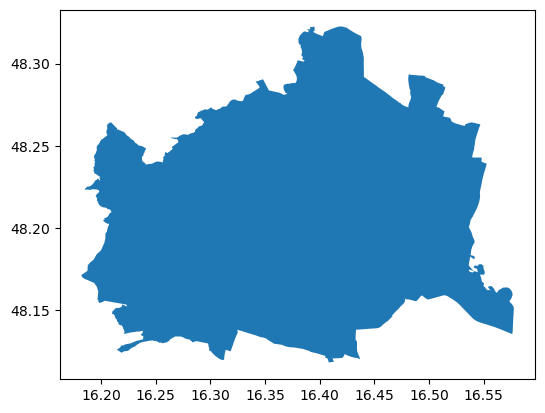

In [4]:
admin_city = ox.geocode_to_gdf('Vienna')
admin_city.plot()
plt.show()
admin_city.to_file("dataframes/admin_city_vienna.geojson", driver="GeoJSON")

In [5]:
file_name = 'data/OEFFGRUENFLOGD.json'
gdf_green = gpd.read_file(file_name)
print(gdf_green.columns)

Index(['id', 'OBJECTID', 'TEXT13ID', 'F_TYP', 'T_TEXT', 'T_LANG', 'O', 'P',
       'O_UEREG', 'O_REGION', 'O_LOKAL', 'P_WLD', 'P_WAS', 'P_WIE', 'P_WGT',
       'P_LW', 'P_PK', 'P_GPK', 'P_GST', 'P_SGR', 'P_AGR', 'P_RGR', 'P_URB',
       'Q_MOB', 'Q_SPI', 'Q_GRI', 'Q_HUN', 'Q_BAB', 'Q_WC', 'Q_SPO', 'Q_TRB',
       'UMFANG', 'FLAECHE', 'SE_ANNO_CAD_DATA', 'geometry'],
      dtype='object')


In [6]:
gdf_green = gdf_green.rename(columns={
    'UMFANG': 'circumference',
    'FLAECHE': 'area'
})

urban_green_spaces = gdf_green[['id', 'OBJECTID', 'T_TEXT', 'T_LANG', 'circumference', 'area', 'geometry']]
print(urban_green_spaces.columns)
green_clipped = gpd.clip(urban_green_spaces, admin_city)

Index(['id', 'OBJECTID', 'T_TEXT', 'T_LANG', 'circumference', 'area',
       'geometry'],
      dtype='object')


In [7]:
print(type(urban_green_spaces))
urban_green_spaces.to_file("dataframes/urban_green_spaces.geojson", driver="GeoJSON")

<class 'geopandas.geodataframe.GeoDataFrame'>


### Blue Spaces Data

**Blue spaces** are "Outdoor environments—natural or manmade—that prominently feature water, and are accessible and offer opportunities for recreation, relaxation, or aesthetic appreciation." (According to the World Health Organization (WHO) and related research (e.g., BlueHealth project))

This includes:
- Oceans and seas
- Rivers, lakes, ponds
- Canals, streams
- Urban fountains, reservoirs (if accessible)
- Wetlands (if part of nature/recreation areas)

They exclude:
- Wastewater facilities
- Industrial drainage systems
- Hidden/underground pipes
- Non-recreational, restricted areas (e.g. dams, treatment plants)


In [8]:
# Define the polygon for the administrative 
admin_poly = admin_city.geometry.values[0]


# Download POIs for blue spaces within the administrative boundary
tags_blue = {
    'natural': ['water', 'wetland'],
    'waterway': ['stream', 'river', 'canal'],
    'water': ['pond', 'lake', 'reservoir', 'basin', 'fishpond']
}
blue = ox.features_from_polygon(admin_poly, tags=tags_blue)

print("Water sources:", len(blue))
print("Type of data:", type(blue))
blue.head(3)

Water sources: 2207
Type of data: <class 'geopandas.geodataframe.GeoDataFrame'>


source  \
element_type osmid                 
node         6813960988      NaN   
way          3870590     landsat   
             3870688     landsat   

                                                                  geometry  \
element_type osmid                                                           
node         6813960988                          POINT (16.41034 48.13083)   
way          3870590     POLYGON ((16.49867 48.27628, 16.4991 48.27635,...   
             3870688     POLYGON ((16.42203 48.23973, 16.42207 48.23983...   

                        created_by odbl river:waterway_distance waterway  \
element_type osmid                                                         
node         6813960988        NaN  NaN                     NaN      NaN   
way          3870590           NaN  NaN                     NaN      NaN   
             3870688           NaN  NaN                     NaN      NaN   

                        seamark:type                 name maxwidth obstacle  \
element_type osmid                                                            
node         6813960988          NaN                  NaN      NaN      NaN   
way          3870590             NaN  Transportbetongrube      NaN      NaN   
             3870688             NaN     Schießstattlacke      NaN      NaN   

                         ... year_of_construction toilets:wheelchair memorial  \
element_type osmid       ...                                                    
node         6813960988  ...                  NaN                NaN      NaN   
way          3870590     ...                  NaN                NaN      NaN   
             3870688     ...                  NaN                NaN      NaN   

                        fence_type abandoned  lit ways attraction name:sh  \
element_type osmid                                                          
node         6813960988        NaN       NaN  NaN  NaN        NaN     NaN   
way          3870590           NaN       NaN  NaN  NaN        NaN     NaN   
             3870688           NaN       NaN  NaN  NaN        NaN     NaN   

                        species:wikidata  
element_type osmid                        
node         6813960988              NaN  
way          3870590                 NaN  
             3870688                 NaN  

[3 rows x 134 columns]

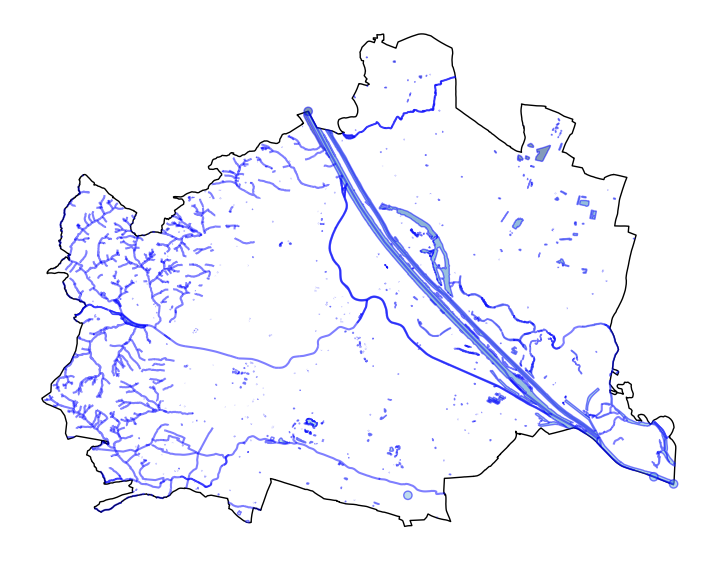

In [9]:
urban_blue_spaces = gpd.clip(blue, admin_city)

# Create a plot to visualize the admin boundary and blue spaces
f, ax = plt.subplots(1, 1, figsize=(9, 9))

# Plot the administrative boundary
admin_city.plot(ax=ax, color='none', edgecolor='k')

# Plot the parks
urban_blue_spaces.plot(ax=ax, cmap='Blues', alpha=0.5, edgecolor='blue')

# Customize the plot
ax.axis('off')
plt.show()

In [10]:
type(urban_blue_spaces)
urban_blue_spaces.to_file("dataframes/urban_blue_spaces.geojson", driver="GeoJSON")

### District & Census District Data
* Census district data contains socio-economic variables
* District data is area, circumference, geometry and name
* Census district data is aggregated based on their location and for every district, socio-economic variables' values found

In [11]:
districts = gpd.read_file('data/vienna_districts.geojson') # districts data from GIS course hw2

districts = districts.rename(columns={
    'UMFANG': 'circumference',
    'FLAECHE': 'area'
})

districts.head(3)

,NAMEK,BEZNR,BEZ_RZ,NAMEK_NUM,NAMEK_RZ,NAMEG,LABEL,BEZ,DISTRICT_C,STATAUSTRI,STATAUSTR0,area,circumference,AKT_TIMEST,SE_SDO_ROW,geometry
0,Hietzing,13.0,XIII,"13., Hietzing",XIII. Hietzing,HIETZING,XIII.,13,1130.0,913.0,91301.0,3.771397e+07,29668.16,2023-07-18,13126.0,"POLYGON ((16.21423 48.20652, 16.21425 48.20651..."
1,Rudolfsheim-Fünfhaus,15.0,XV,"15., Rudolfsheim-Fünfhaus",XV. Rudolfsheim-Fünfhaus,RUDOLFSHEIM-FÜNFHAUS,XV.,15,1150.0,915.0,91501.0,3.916953e+06,9711.71,2023-07-18,13127.0,"POLYGON ((16.32732 48.205, 16.33366 48.20406, ..."
2,Neubau,7.0,VII,"7., Neubau",VII. Neubau,NEUBAU,VII.,07,1070.0,907.0,90701.0,1.608248e+06,5312.54,2023-07-18,13128.0,"POLYGON ((16.33873 48.20854, 16.33901 48.20849..."


In [12]:
gdf_census = gpd.read_file('data/data_ssi.geojson')
print(len(gdf_census))

246


In [13]:
# Spatial join in order to find socio-economic indicators in district scale as well. 
# This will be used later on to understand whether i can use average income as a proxy for rental prices or not.

gdf_census = gdf_census.to_crs(districts.crs)

# Attaching district info to each census district
gdf_joined = gpd.sjoin(gdf_census, districts[['geometry', 'NAMEK_NUM']], how='left', predicate='intersects')

# Group by district name and taking the average
socio_vars = ['avg_income', 'unemprate', 'university_share', 'benefit_share', 'SSI']  # all socio-economic variables
district_stats = gdf_joined.groupby('NAMEK_NUM')[socio_vars].mean().reset_index()
district_stats.rename(columns={
    'avg_income': 'district_avgincome',
    'unemprate': 'district_unemprate',
    'university_share': 'district_univshare',
    'benefit_share': 'district_benefitshare',
    'SSI': 'district_SSI'
}, inplace=True)

socioecon_districts = districts.merge(district_stats, on='NAMEK_NUM', how='left')

In [14]:
print(len(socioecon_districts))
socioecon_districts.head(3)

23


,NAMEK,BEZNR,BEZ_RZ,NAMEK_NUM,NAMEK_RZ,NAMEG,LABEL,BEZ,DISTRICT_C,STATAUSTRI,...,area,circumference,AKT_TIMEST,SE_SDO_ROW,geometry,district_avgincome,district_unemprate,district_univshare,district_benefitshare,district_SSI
0,Hietzing,13.0,XIII,"13., Hietzing",XIII. Hietzing,HIETZING,XIII.,13,1130.0,913.0,...,3.771397e+07,29668.16,2023-07-18,13126.0,"POLYGON ((16.21423 48.20652, 16.21425 48.20651...",0.642256,0.369003,0.549082,0.285477,0.561803
1,Rudolfsheim-Fünfhaus,15.0,XV,"15., Rudolfsheim-Fünfhaus",XV. Rudolfsheim-Fünfhaus,RUDOLFSHEIM-FÜNFHAUS,XV.,15,1150.0,915.0,...,3.916953e+06,9711.71,2023-07-18,13127.0,"POLYGON ((16.32732 48.205, 16.33366 48.20406, ...",-0.591063,-0.260053,0.175842,-0.071401,-0.214924
2,Neubau,7.0,VII,"7., Neubau",VII. Neubau,NEUBAU,VII.,07,1070.0,907.0,...,1.608248e+06,5312.54,2023-07-18,13128.0,"POLYGON ((16.33873 48.20854, 16.33901 48.20849...",0.409909,0.407823,1.101009,0.588805,0.743321


In [15]:
print(type(socioecon_districts))
socioecon_districts.to_file("dataframes/socioecon_districts.geojson", driver="GeoJSON")

<class 'geopandas.geodataframe.GeoDataFrame'>


### UGBS per Census District

* both blue and green spaces are clipped for city
* blue lines are buffered with 10m
* all blue spaces shifted into area format
* ugbs data is combined with census district data allowing to see total green and blue spaces per census district with socio-economic variables

In [16]:
# epsg 4326 is coordinates, and not good for area and periphery calculations. 
# need to change their crs. Target crs: epsg=31256

gdf_census = gdf_census.to_crs(epsg=31256)
urban_green_spaces = urban_green_spaces.to_crs(epsg=31256)
admin_city = admin_city.to_crs(epsg=31256)
blue = blue.to_crs(epsg=31256)

In [17]:
print(urban_green_spaces.geometry.type.unique())
print(blue.geometry.type.unique())

# in order to overlay, I need same types of geometries
# seperate blue geometries into 2 different gdf: blue_lines, blue_areas

# Separate blue space geometries by type
blue_areas = blue[blue.geometry.type.isin(['Polygon', 'MultiPolygon'])].copy()
blue_lines = blue[blue.geometry.type.isin(['LineString', 'MultiLineString'])].copy()

print(blue_areas.geometry.type.unique())
print(blue_lines.geometry.type.unique())

['MultiPolygon' 'Polygon']
['Point' 'Polygon' 'LineString' 'MultiPolygon']
['Polygon' 'MultiPolygon']
['LineString']


In [18]:
# Choose a reasonable buffer (in meters)
blue_lines_buffered = blue_lines.copy()
blue_lines_buffered['geometry'] = blue_lines_buffered.to_crs(epsg=31256).buffer(10)  # ~10m width
blue_lines_buffered = blue_lines_buffered.to_crs(blue.crs)  # return to original CRS

# Combine with actual polygons
blue_areas_total = pd.concat([blue_areas, blue_lines_buffered], ignore_index=True)
blue_areas_total.head(3)

,source,geometry,created_by,odbl,river:waterway_distance,waterway,seamark:type,name,maxwidth,obstacle,...,year_of_construction,toilets:wheelchair,memorial,fence_type,abandoned,lit,ways,attraction,name:sh,species:wikidata
0,landsat,"POLYGON ((12361.826 348671.604, 12393.61 34867...",NaN,NaN,NaN,NaN,NaN,Transportbetongrube,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,landsat,"POLYGON ((6677.263 344598.658, 6680.698 344609...",NaN,NaN,NaN,NaN,NaN,Schießstattlacke,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,"POLYGON ((6275.055 344535.063, 6275.568 344534...",NaN,NaN,NaN,NaN,NaN,Irissee,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# green areas per district
green_clipped_proj = green_clipped.to_crs(gdf_census.crs)
green_in_census = gpd.overlay(gdf_census, green_clipped_proj, how='identity', keep_geom_type=False)
green_in_census['green_area'] = green_in_census.geometry.area
print(green_in_census.columns.tolist())

['ZBEZ', 'university_share', 'avg_income', 'unemprate', 'benefit_share', 'SSI', 'quintile', 'id', 'OBJECTID', 'T_TEXT', 'T_LANG', 'circumference', 'area', 'geometry', 'green_area']


In [20]:
# blue areas per district
blue_proj = blue_areas_total.to_crs(gdf_census.crs)
blue_in_census = gpd.overlay(gdf_census, blue_proj, how='identity')
blue_in_census['blue_area'] = blue_in_census.geometry.area
blue_in_census.head(3)

# 1. Get shared columns
common_cols = list(set(green_in_census.columns) & set(blue_in_census.columns))
print("Shared columns:", common_cols)

# 2. Optionally exclude the join key (e.g. 'ZBEZ') and geometry
cols_to_drop = [col for col in common_cols if col not in ['ZBEZ', 'geometry']]

# 3. Drop shared columns from blue_in_census before merge
blue_in_census_cleaned = blue_in_census.drop(columns=cols_to_drop)

# 4. Merge
ugbs_census = green_in_census.merge(blue_in_census_cleaned, on='ZBEZ', how='left')
#print(ugbs_census.columns.tolist())
ugbs_census_clean = ugbs_census[['ZBEZ', 'university_share', 'avg_income', 'unemprate', 'benefit_share', 'SSI', 'quintile', 'geometry_x', 'geometry_y', 'green_area', 'blue_area']]
print(len(ugbs_census_clean))
ugbs_census_clean.head(5)

Shared columns: ['area', 'quintile', 'unemprate', 'benefit_share', 'university_share', 'ZBEZ', 'avg_income', 'SSI', 'geometry']
47448


,ZBEZ,university_share,avg_income,unemprate,benefit_share,SSI,quintile,geometry_x,geometry_y,green_area,blue_area
0,0101,1.604954,1.741399,1.125923,1.123008,1.653992,5.0,"POLYGON ((3497.002 341023.556, 3494.089 341024...","POLYGON ((3129.491 340896.774, 3129.5 340894.7...",37.380483,16.971625
1,0101,1.604954,1.741399,1.125923,1.123008,1.653992,5.0,"POLYGON ((3497.002 341023.556, 3494.089 341024...","POLYGON ((3486.189 341497.846, 3487.929 341497...",37.380483,377540.239756
2,0101,1.604954,1.741399,1.125923,1.123008,1.653992,5.0,"POLYGON ((3486.189 341497.846, 3487.929 341497...","POLYGON ((3129.491 340896.774, 3129.5 340894.7...",1139.371257,16.971625
3,0101,1.604954,1.741399,1.125923,1.123008,1.653992,5.0,"POLYGON ((3486.189 341497.846, 3487.929 341497...","POLYGON ((3486.189 341497.846, 3487.929 341497...",1139.371257,377540.239756
4,0102,1.653812,2.565233,1.237000,1.139440,2.000434,5.0,"MULTIPOLYGON (((3696.979 340797.926, 3696.649 ...","POLYGON ((3489.529 340479.256, 3489.436 340479...",69635.658363,30534.074489


In [21]:
# Step 1: Drop duplicate geometries per ZBEZ for green areas
green_unique = ugbs_census_clean[['ZBEZ', 'geometry_x', 'green_area']].drop_duplicates(subset=['ZBEZ', 'geometry_x'])
green_agg = green_unique.groupby('ZBEZ')['green_area'].sum().reset_index()
green_agg.rename(columns={'green_area': 'green_area_sum'}, inplace=True)
print(len(green_agg))

# Step 2: Do the same for blue areas
blue_unique = ugbs_census_clean[['ZBEZ', 'geometry_y', 'blue_area']].drop_duplicates(subset=['ZBEZ', 'geometry_y'])
blue_agg = blue_unique.groupby('ZBEZ')['blue_area'].sum().reset_index()
blue_agg.rename(columns={'blue_area': 'blue_area_sum'}, inplace=True)
print(len(blue_agg))

# Step 3: Get socio-economic variables (they're identical per ZBEZ)
socio_vars = ['university_share', 'avg_income', 'unemprate', 'benefit_share', 'SSI', 'quintile']
socio_agg = ugbs_census_clean.groupby('ZBEZ')[socio_vars].first().reset_index()
print(len(socio_agg))

# Step 4: Pick one geometry per ZBEZ for final GeoDataFrame (e.g., geometry_x)
geometry_per_zbez = ugbs_census_clean[['ZBEZ', 'geometry_x']].drop_duplicates(subset='ZBEZ')


# Step 5: Merge everything
ugbs_census_final = socio_agg \
    .merge(green_agg, on='ZBEZ', how='left') \
    .merge(blue_agg, on='ZBEZ', how='left') \
    .merge(geometry_per_zbez, on='ZBEZ', how='left')

# Step 6: Set 'geometry_x' as active geometry column
ugbs_census_final = pd.DataFrame(ugbs_census_final)  # ensure it's a DataFrame first
ugbs_census_final = gpd.GeoDataFrame(ugbs_census_final)  # convert to GeoDataFrame

ugbs_census_final.set_geometry('geometry_x', inplace=True)

# Step 7: Now set the CRS using original source
#ugbs_census_final.set_crs(ugbs_census_clean.crs, inplace=True)

# Rename to standard 'geometry'
ugbs_census_final = ugbs_census_final.rename_geometry("geometry")

print(ugbs_census_final.crs)
print(type(ugbs_census_final))
print(len(ugbs_census_final))
ugbs_census_final.head(5)
# print(ugbs_census_final['ZBEZ'].to_list())

246
246
246
EPSG:31256
<class 'geopandas.geodataframe.GeoDataFrame'>
246


,ZBEZ,university_share,avg_income,unemprate,benefit_share,SSI,quintile,green_area_sum,blue_area_sum,geometry
0,0101,1.604954,1.741399,1.125923,1.123008,1.653992,5.0,377557.211380,377557.211380,"POLYGON ((3497.002 341023.556, 3494.089 341024..."
1,0102,1.653812,2.565233,1.237000,1.139440,2.000434,5.0,379376.751386,402127.190695,"MULTIPOLYGON (((3696.979 340797.926, 3696.649 ..."
2,0103,1.706598,3.805033,1.641029,1.232519,2.570582,5.0,465496.860383,465496.860383,"MULTIPOLYGON (((2656.019 340238.286, 2647.079 ..."
3,0104,1.845975,3.156000,1.697713,1.313290,2.407460,5.0,835823.045243,835823.045243,"POLYGON ((2506.199 340562.476, 2402.249 340597..."
4,0105,1.681303,2.424953,1.192502,1.252134,1.971322,5.0,333293.038103,333293.038103,"POLYGON ((3148.316 341741.767, 3147.44 341743...."


In [22]:
# Ensure CRS is projected in meters before area calculation
gdf_census = gdf_census.to_crs(epsg=31287)

# Compute area in square meters and convert to square kilometers
gdf_census['census_area_m2'] = gdf_census.geometry.area
# gdf_census['census_area_km2'] = gdf_census['census_area_m2'] / 1e6

# Keep only needed columns and merge
area_df = gdf_census[['ZBEZ', 'census_area_m2']]
ugbs_census_final = ugbs_census_final.merge(area_df, on='ZBEZ', how='left')

ugbs_census_final['green_ratio'] = ugbs_census_final['green_area_sum'] / ugbs_census_final['census_area_m2']
ugbs_census_final['blue_ratio'] = ugbs_census_final['blue_area_sum'] / ugbs_census_final['census_area_m2']
ugbs_census_final[['green_ratio', 'blue_ratio']] = ugbs_census_final[['green_ratio', 'blue_ratio']].round(3)

In [23]:
ugbs_census_final.head(3)

,ZBEZ,university_share,avg_income,unemprate,benefit_share,SSI,quintile,green_area_sum,blue_area_sum,geometry,census_area_m2,green_ratio,blue_ratio
0,0101,1.604954,1.741399,1.125923,1.123008,1.653992,5.0,377557.211380,377557.211380,"POLYGON ((3497.002 341023.556, 3494.089 341024...",377355.802538,1.001,1.001
1,0102,1.653812,2.565233,1.237000,1.139440,2.000434,5.0,379376.751386,402127.190695,"MULTIPOLYGON (((3696.979 340797.926, 3696.649 ...",379174.177693,1.001,1.061
2,0103,1.706598,3.805033,1.641029,1.232519,2.570582,5.0,465496.860383,465496.860383,"MULTIPOLYGON (((2656.019 340238.286, 2647.079 ...",465247.393063,1.001,1.001


In [24]:
print(type(ugbs_census_final))
print(len(ugbs_census_final))
ugbs_census_final.to_file("dataframes/ugbs_socioecon_census.geojson",  driver="GeoJSON")

<class 'geopandas.geodataframe.GeoDataFrame'>
246


### Housing Prices Data
District Scale

In [25]:
housing_path = "data/SpecialEvaluation.ods" 
housing_data = pd.read_excel(housing_path, engine="odf", sheet_name=None)

# Show available sheets
print(housing_data.keys())

dict_keys(['Apartment_Prices', 'House_Prices', 'Building_Plots', 'Federal_Provinces', 'Apartment_Prices_municipalities', 'House_Prices_municipalities', 'Fed__states_and_constr__Periods'])


In [26]:
housing_data = pd.read_excel(
    housing_path,
    engine="odf",
    sheet_name="Apartment_Prices",  
    header=1                        # use row 2 as column names
)
housing_data.columns

Index(['D. CD.', 'Districts', 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023],
      dtype='object')

In [27]:
# Keep only Vienna rows, Wiener Neustadt is not in Vienna in terms of state boundaries
housing_vienna = housing_data[
    housing_data['Districts'].str.contains('Wien', na=False) &
    ~housing_data['Districts'].str.contains('Wiener Neustadt', na=False)
]
housing_vienna.columns = housing_vienna.columns.astype(str)

housing_vienna.loc[:, 'district_clean'] = housing_vienna['Districts'].str.split(',').str[1].str.strip()
housing_vienna.head(5)

/var/folders/fg/tx5hq3917p5dxc674m9h_4500000gn/T/ipykernel_19044/2484245388.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  housing_vienna.loc[:, 'district_clean'] = housing_vienna['Districts'].str.split(',').str[1].str.strip()


,D. CD.,Districts,2015,2016,2017,2018,2019,2020,2021,2022,2023,district_clean
93,901,"Wien 1.,Innere Stadt",6569,7861,9368,10955,11186,10947,13078,14389,12733,Innere Stadt
94,902,"Wien 2.,Leopoldstadt",3650,4125,4327,4482,4590,5215,5331,6181,5494,Leopoldstadt
95,903,"Wien 3.,Landstraße",3934,4039,4483,4787,4375,5483,5715,5850,5635,Landstraße
96,904,"Wien 4.,Wieden",4189,4237,4932,5195,5650,5586,6471,7776,6646,Wieden
97,905,"Wien 5.,Margareten",3272,3500,3548,3662,3796,4634,5648,5440,4562,Margareten


In [28]:
# Merging housing prices data into districts GeoDataFrame
housingprices_district = districts.merge(
    housing_vienna[['district_clean', '2015', '2016', '2017', '2018', '2019', '2020',  '2021', '2022', '2023']],
    left_on='NAMEK',
    right_on='district_clean',
    how='left'
)

year_cols = ['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']
housingprices_district['avg_price_years'] = housingprices_district[year_cols].mean(axis=1)
housingprices_district['avg_price_years'] = housingprices_district['avg_price_years'].round(2)

In [29]:
pd.set_option('display.precision', 2)
housingprices_district.head(3)

,NAMEK,BEZNR,BEZ_RZ,NAMEK_NUM,NAMEK_RZ,NAMEG,LABEL,BEZ,DISTRICT_C,STATAUSTRI,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,avg_price_years
0,Hietzing,13.0,XIII,"13., Hietzing",XIII. Hietzing,HIETZING,XIII.,13,1130.0,913.0,...,4232,4132,4043,4423,4462,4821,5593,6159,5327,4799.11
1,Rudolfsheim-Fünfhaus,15.0,XV,"15., Rudolfsheim-Fünfhaus",XV. Rudolfsheim-Fünfhaus,RUDOLFSHEIM-FÜNFHAUS,XV.,15,1150.0,915.0,...,2429,3369,3315,3827,3860,4111,4729,4460,4215,3812.78
2,Neubau,7.0,VII,"7., Neubau",VII. Neubau,NEUBAU,VII.,07,1070.0,907.0,...,4774,4553,4755,5405,5833,6043,6332,6336,5929,5551.11


In [30]:
type(housingprices_district)
housingprices_district.to_file("dataframes/housingprices_district.geojson", driver="GeoJSON")

## Census District Boundaries & Housing Data
* both from data.gov.aut
* 1st for geometry and coordinates
* 2nd for apartments, room numbers, heating etc - features of homes per census district

In [31]:
boundaries_path = 'data/ZAEHLBEZIRKOGDPolygon.shp'
census_boundaries = gpd.read_file(boundaries_path)
census_boundaries

,BEZNR,ZBEZNR,BEZ,ZBEZ,FLAECHE,UMFANG,AKT_TIMEST,SE_SDO_ROW,geometry
0,22.0,19.0,22,2219,431562.49,2963.93,2025-05-10,305665.0,"POLYGON ((16.46046 48.22702, 16.45954 48.22574..."
1,19.0,9.0,19,1909,700939.31,3670.56,2025-05-10,305666.0,"POLYGON ((16.33778 48.23599, 16.33778 48.237, ..."
2,9.0,2.0,09,0902,471286.96,3510.43,2025-05-10,305667.0,"POLYGON ((16.36283 48.22965, 16.36284 48.22965..."
3,8.0,1.0,08,0801,267754.53,2218.68,2025-05-10,305664.0,"POLYGON ((16.35112 48.21496, 16.35315 48.21484..."
4,5.0,2.0,05,0502,671172.39,4660.74,2025-05-10,305668.0,"POLYGON ((16.36695 48.18575, 16.36777 48.18492..."
...,...,...,...,...,...,...,...,...,...
245,5.0,4.0,05,0504,289684.67,3137.66,2025-05-10,305691.0,"POLYGON ((16.35351 48.19122, 16.35352 48.19123..."
246,11.0,13.0,11,1113,757083.38,5274.62,2025-05-10,305675.0,"POLYGON ((16.43135 48.1654, 16.43223 48.16518,..."
247,22.0,10.0,22,2210,987956.67,5364.86,2025-05-10,305676.0,"POLYGON ((16.43651 48.25009, 16.43646 48.24982..."
248,10.0,6.0,10,1006,512584.42,3289.76,2025-05-10,305677.0,"POLYGON ((16.37232 48.18003, 16.37233 48.17989..."


In [32]:
apartment_features_path = 'data/vie_apartments_wohnungen_2021.csv'
apartment_features = pd.read_csv(apartment_features_path, delimiter=';', header=1)
apartment_features.head(3)

,NUTS1,NUTS2,NUTS3,DISTRICT_CODE,SUB_DISTRICT_CODE,WHG_TOTAL,WHG_WSA_0,WHG_WSA_1,WHG_NOC_0,WHG_NOC_1,...,OBJ_BAUP_7,OBJ_BAUP_8,OBJ_BAUP_9,OBJ_ANZWHG_1,OBJ_ANZWHG_2,OBJ_ANZWHG_3,OBJ_ANZWHG_4,OBJ_ANZWHG_5,OBJ_ANZWHG_6,REF_DATE
0,AT1,AT13,AT130,90100,90101,2686,592,2094,592,1138,...,26,0,19,25,32,235,680,930,784,20211031
1,AT1,AT13,AT130,90100,90102,945,198,747,198,354,...,4,1,9,7,6,77,299,327,229,20211031
2,AT1,AT13,AT130,90100,90103,1294,264,1030,264,491,...,25,0,16,17,32,103,428,563,151,20211031


In [33]:
apartment_features.columns = apartment_features.columns.str.strip().str.upper()

In [34]:
apt_features_final = apartment_features[[
    "DISTRICT_CODE", "SUB_DISTRICT_CODE", "WHG_TOTAL",
    "WHG_BEHEIZ_0", "WHG_BEHEIZ_1",
    "OBJ_EIGENT_1", "OBJ_EIGENT_2", "OBJ_EIGENT_3", "OBJ_EIGENT_4"
]]

# Rename columns based on provided definitions
apt_features_final.columns = [
    "district_code",                # DISTRICT_CODE → Municipal district code
    "census_district_code",         # SUB_DISTRICT_CODE → Census district code
    "total_apartments",             # WHG_TOTAL → Total apartments
    "no_central_heating",           # WHG_BEHEIZ_0 → No central heating
    "central_heating",              # WHG_BEHEIZ_1 → Central heating
    "owner_private",    # OBJ_EIGENT_1 → Private individual(s)
    "owner_public",    # OBJ_EIGENT_2 → Public corporations
    "owner_nonprofit",        # OBJ_EIGENT_3 → Non-profit building associations
    "owner_other"            # OBJ_EIGENT_4 → Other legal entity
]

apt_features_final.head(5)

,district_code,census_district_code,total_apartments,no_central_heating,central_heating,owner_private,owner_public,owner_nonprofit,owner_other
0,90100,90101,2686,94,2592,1271,483,4,928
1,90100,90102,945,31,914,559,33,4,349
2,90100,90103,1294,34,1260,708,74,0,512
3,90100,90104,922,36,886,418,200,0,304
4,90100,90105,1302,51,1251,610,217,13,462


In [35]:
apt_features_final.to_csv("dataframes/apt_features_final_census.csv", index=False)